# Mini-Project 3: Lake Victoria Fish Stock & Export Risk Model

**Scenario.** A fish-export cooperative in Jinja asks two questions: (a) is our harvesting rate sustainable, and (b) how risky is our revenue? The previous version of this question modelled stock with Fibonacci numbers and flagged risk whenever revenue variance exceeded 50,000. I replace both with defensible methods and explain why the old ones fail.

**My approach** (classes in `src/fisheries.py`):
* `FishStock`: discrete logistic growth with proportional harvesting, plus an optional closed season.
* `PriceModel`: a seeded, bounded random walk for the weekly price.
* `RiskAssessor`: statistics, a CV-based risk rule, Monte Carlo simulation and Value-at-Risk.

These are composed rather than inherited: revenue = `FishStock` harvest × `PriceModel` price, and `RiskAssessor` consumes the result. Each class has one job.

**Assumptions.**
* Time step = 1 week, so r = 0.4 is a **weekly** intrinsic growth rate. That is very fast for fish (it suits a fast-breeding species such as *mukene*/silver cyprinid better than Nile perch). I keep it because the brief specifies it.
* Harvest each week = h × N(t), landed and sold that week. Stock is in tonnes; revenue = tonnes × 1,000 kg × UGX/kg.
* Prices are illustrative: a random walk starting at UGX 12,000/kg, weekly step σ = UGX 400, clipped to [9,000, 16,000].

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fisheries import (FishStock, PriceModel, RiskAssessor, fibonacci, weekly_revenue,
                           WEEKS_PER_YEAR)

PRICE_SEED, MC_SEED = 7, 99
N_PATHS = 1000
HARVEST_RATES = [0.05, 0.10, 0.20, 0.30]
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## Task 1: Fibonacci baseline

In [2]:
fib_stock = fibonacci(15)
print("Fibonacci 'stock':", fib_stock)
print("Growth ratios of the last terms:", [round(fib_stock[i + 1] / fib_stock[i], 3) for i in range(10, 14)])

Fibonacci 'stock': [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]
Growth ratios of the last terms: [1.618, 1.618, 1.618, 1.618]


**Why unbounded Fibonacci growth is biologically unrealistic.** In the Fibonacci sequence, each term is the sum of the previous two, so the "stock" grows by about 62 % every period *forever*. Real fish populations are limited by food, oxygen, breeding habitat and predation, so growth must slow as the lake fills up: there is a **carrying capacity**. The sequence also has no mortality and no harvesting term, so it can never decline, and fishing pressure (the cooperative's actual decision variable) has no effect at all. Finally, growth in the sequence does not depend on how crowded the population is. That is why the logistic model, in which the growth rate falls as N approaches K, is the standard minimal model in fisheries science (Schaefer, 1954).

## Task 2: `FishStock` with logistic growth and harvesting

$$N_{t+1} = N_t + r N_t \left(1 - \frac{N_t}{K}\right) - h N_t, \qquad r = 0.4,\; K = 10{,}000\text{ t},\; N_0 = 4{,}000\text{ t}$$

In [3]:
base_stock = FishStock(r=0.4, K=10_000, N0=4_000, h=0.10)
sim = base_stock.simulate(WEEKS_PER_YEAR)
print(base_stock)
print(f"Week 0 -> 1 (hand): 4000 + 0.4*4000*(1-0.4) - 0.1*4000 = {4000 + 0.4 * 4000 * 0.6 - 400:.0f};  model: {sim.stock[1]:.0f}")
print(f"Final stock after 52 weeks: {sim.final_stock:,.1f} t  (theory: K(1-h/r) = {base_stock.equilibrium_stock():,.0f} t)")
print(f"Total harvest: {sim.total_harvest:,.0f} t;  mean weekly harvest {sim.harvest.mean():,.1f} t")

FishStock(r=0.4, K=10000, N0=4000, h=0.1, closed_weeks=frozenset())
Week 0 -> 1 (hand): 4000 + 0.4*4000*(1-0.4) - 0.1*4000 = 4560;  model: 4560
Final stock after 52 weeks: 7,500.0 t  (theory: K(1-h/r) = 7,500 t)
Total harvest: 37,363 t;  mean weekly harvest 718.5 t


**Theory as a cross-check.** Setting N_{t+1} = N_t gives the non-zero equilibrium **N\* = K(1 − h/r)**, with sustainable yield **Y(h) = h·K(1 − h/r)**. This is maximised at **h = r/2 = 0.2**, giving **MSY = rK/4 = 1,000 t/week** at N\* = K/2 = 5,000 t. The simulation converges to N\* within the 52 weeks, which confirms the code.

## Task 3: `PriceModel` (bounded random walk) and weekly revenue

In [4]:
price_model = PriceModel(start=12_000, low=9_000, high=16_000, step_sd=400, seed=PRICE_SEED)
prices = price_model.simulate(WEEKS_PER_YEAR)
revenue = weekly_revenue(sim.harvest, prices)          # UGX
print(price_model)
print(f"Price range on this path: {prices.min():,.0f} to {prices.max():,.0f} UGX/kg")
print(f"Week 1 revenue: {sim.harvest[0]:.1f} t x 1000 kg x {prices[0]:,.0f} = UGX {revenue[0]:,.0f}")

PriceModel(start=12000, low=9000, high=16000, step_sd=400, seed=7)
Price range on this path: 9,000 to 12,120 UGX/kg
Week 1 revenue: 400.0 t x 1000 kg x 12,000 = UGX 4,800,000,000


## Task 4: Revenue statistics and why "variance > 50,000" is meaningless

In [5]:
stats = RiskAssessor.summary(revenue)
print(f"mean     UGX {stats['mean']:,.0f}")
print(f"median   UGX {stats['median']:,.0f}")
print(f"variance UGX^2 {stats['variance']:,.3e}")
print(f"stdev    UGX {stats['stdev']:,.0f}")
print(f"CV       {stats['cv']:.3f}")
print("\nThe same revenue expressed in different units:")
print(f"in UGX        : variance = {stats['variance']:.3e} UGX^2 | > 50,000? {stats['variance'] > 50_000}")
for unit, scale in [("UGX million", 1e6), ("UGX billion", 1e9)]:
    s_u = RiskAssessor.summary(revenue / scale)
    print(f"in {unit:11s}: variance = {s_u['variance']:,.3f} ({unit})^2 | > 50,000? {s_u['variance'] > 50_000} | CV = {s_u['cv']:.3f}")

mean     UGX 7,158,377,744
median   UGX 6,906,298,550
variance UGX^2 5.621e+17
stdev    UGX 749,729,536
CV       0.105

The same revenue expressed in different units:
in UGX        : variance = 5.621e+17 UGX^2 | > 50,000? True
in UGX million: variance = 562,094.377 (UGX million)^2 | > 50,000? True | CV = 0.105
in UGX billion: variance = 0.562 (UGX billion)^2 | > 50,000? False | CV = 0.105


**The units of variance are UGX².** Variance is the mean squared deviation, so its unit is the square of the revenue unit. With weekly revenue in the billions of UGX, the variance is around 10¹⁸ UGX². Any revenue series of this size, however stable, "exceeds 50,000". Record the same data in millions of UGX and the variance drops by a factor of 10¹² (still above 50,000). In billions of UGX it drops by 10¹⁸ and suddenly falls *below* the threshold, while the CV stays exactly the same. A rule whose verdict depends on whether you write "UGX" or "UGX billion" measures the *units*, not the risk. The threshold also ignores scale: a ±UGX 1 million swing is negligible for a business turning over billions but catastrophic for one turning over 2 million.

The **coefficient of variation (CV = σ/μ)** fixes both problems. It is unit-free (the test `test_cv_is_scale_free_but_variance_is_not` proves this) and expresses volatility as a fraction of typical income.

## Task 5: `RiskAssessor` with a CV-based rule, Monte Carlo and VaR

**Risk rule (justified).**

| CV of weekly revenue | Class | Interpretation |
|---|---|---|
| < 0.10 | Low | a typical week is within ±10 % of average income; easy to absorb with a small cash buffer |
| 0.10–0.25 | Moderate | swings of 10–25 %; needs about a month of reserves or a credit line |
| ≥ 0.25 | High | a one-σ bad week loses a quarter of income; wages and loan repayments are at risk |

The bands follow the common rule of thumb in agricultural risk analysis that CV < 10 % is "stable" and CV > 25–30 % is "highly variable". The cut-offs are a judgement call, so I state them explicitly and make them constructor parameters.

**Why Monte Carlo.** One price path is one possible future. I simulate **1,000 price paths** and, for each, the annual revenue (harvest is deterministic given h). Classification uses the **average weekly CV across all paths**, so a lucky or unlucky single path does not decide the risk class. The **5 % Value-at-Risk** is the annual revenue that is beaten in 95 % of simulated years; I report it both as a level and as a shortfall from the mean.

In [6]:
assessor = RiskAssessor(low_cv=0.10, high_cv=0.25)
paths = price_model.simulate_paths(WEEKS_PER_YEAR, N_PATHS, seed=MC_SEED)   # (1000, 52)
annual = weekly_revenue(sim.harvest, paths).sum(axis=1)
var = assessor.value_at_risk(annual, level=0.05)
print(f"h = 0.10 | mean annual revenue  UGX {var['mean'] / 1e9:,.1f} bn")
print(f"         | 5% quantile         UGX {var['quantile'] / 1e9:,.1f} bn")
print(f"         | 95% VaR (shortfall) UGX {var['var'] / 1e9:,.1f} bn below the mean")
print(f"         | expected weekly CV  {assessor.mean_path_cv(weekly_revenue(sim.harvest, paths)):.3f} -> "
      f"{assessor.classify_paths(weekly_revenue(sim.harvest, paths))}")
# second-method check: the quantile by sorting
print("check by sorting:", np.isclose(np.sort(annual)[int(0.05 * (N_PATHS - 1))], var["quantile"], rtol=1e-3))

h = 0.10 | mean annual revenue  UGX 450.2 bn
         | 5% quantile         UGX 373.6 bn
         | 95% VaR (shortfall) UGX 76.6 bn below the mean
         | expected weekly CV  0.131 -> Moderate
check by sorting: True


## Task 6: Scenario analysis for h = 0.05, 0.10, 0.20, 0.30

In [7]:
rows, trajectories, annual_by_h = [], {}, {}
for h in HARVEST_RATES:
    stock = FishStock(h=h)
    res = stock.simulate(WEEKS_PER_YEAR)
    trajectories[h] = res.stock
    rev_paths = weekly_revenue(res.harvest, paths)
    annual_h = rev_paths.sum(axis=1)
    annual_by_h[h] = annual_h
    v = assessor.value_at_risk(annual_h)
    rows.append({
        "h": h,
        "final stock (t)": res.final_stock,
        "equilibrium N* (t)": stock.equilibrium_stock(),
        "mean weekly harvest (t)": res.harvest.mean(),
        "sustainable yield hN* (t/wk)": stock.equilibrium_yield(),
        "% of MSY": 100 * stock.equilibrium_yield() / stock.msy,
        "total revenue, base path (UGX bn)": weekly_revenue(res.harvest, prices).sum() / 1e9,
        "MC mean annual (UGX bn)": v["mean"] / 1e9,
        "5% VaR shortfall (UGX bn)": v["var"] / 1e9,
        "weekly CV": assessor.mean_path_cv(rev_paths),
        "risk class": assessor.classify_paths(rev_paths),
    })
scenarios = pd.DataFrame(rows).set_index("h")
print(f"MSY = rK/4 = {FishStock().msy:,.0f} t/week at h = r/2 = {FishStock().r / 2}")
scenarios

MSY = rK/4 = 1,000 t/week at h = r/2 = 0.2


,final stock (t),equilibrium N* (t),mean weekly harvest (t),sustainable yield hN* (t/wk),% of MSY,"total revenue, base path (UGX bn)",MC mean annual (UGX bn),5% VaR shortfall (UGX bn),weekly CV,risk class
h,,,,,,,,,,
0.05,"8,750.00","8,750.00",417.59,437.50,43.75,216.16,261.65,44.81,0.14,Moderate
0.10,"7,500.00","7,500.00",718.51,750.00,75.00,372.24,450.19,76.63,0.13,Moderate
0.20,"4,999.99","5,000.00",978.30,"1,000.00",100.00,508.90,612.92,101.67,0.09,Low
0.30,"2,503.72","2,500.00",816.56,750.00,75.00,431.08,511.41,79.24,0.15,Moderate


**Interpretation against MSY.**
* **h = 0.20 is the MSY rate.** The stock settles at K/2 = 5,000 t, the sustainable harvest is 1,000 t/week (100 % of MSY), and it gives the highest revenue *and* the most stable weekly income (Low risk). The harvest barely changes over the year because the stock starts close to its equilibrium.
* **h = 0.05 and 0.10 are under-fishing.** The stock is healthy (8,750 t and 7,500 t), but the co-op leaves revenue on the lake: 44 % and 75 % of MSY. Their weekly CV is higher because the stock is still *growing* towards equilibrium, so harvests climb through the year.
* **h = 0.30 is over-fishing, and it is a trap.** The sustainable yield is exactly the same as at h = 0.10 (750 t/week = 0.3 × 2,500 = 0.1 × 7,500), but the stock is driven down to **2,500 t, a quarter of carrying capacity**. In year one, h = 0.30 looks *better* than h = 0.10 (higher mean harvest and revenue) because the co-op is **mining the existing stock**: the 52-week mean harvest (≈ 817 t) exceeds the long-run sustainable 750 t. That short-term windfall is exactly how over-fishing goes unnoticed. A low stock is also more vulnerable to shocks (a bad breeding year, illegal fishing) because recovery depends on the stock size.

So the answer to "is our harvesting rate sustainable?" is: every rate below r = 0.4 is mathematically sustainable in this model, but only h ≈ 0.2 maximises the yield, and h > 0.2 buys short-term revenue at the cost of a fragile stock.

## Task 7: Charts

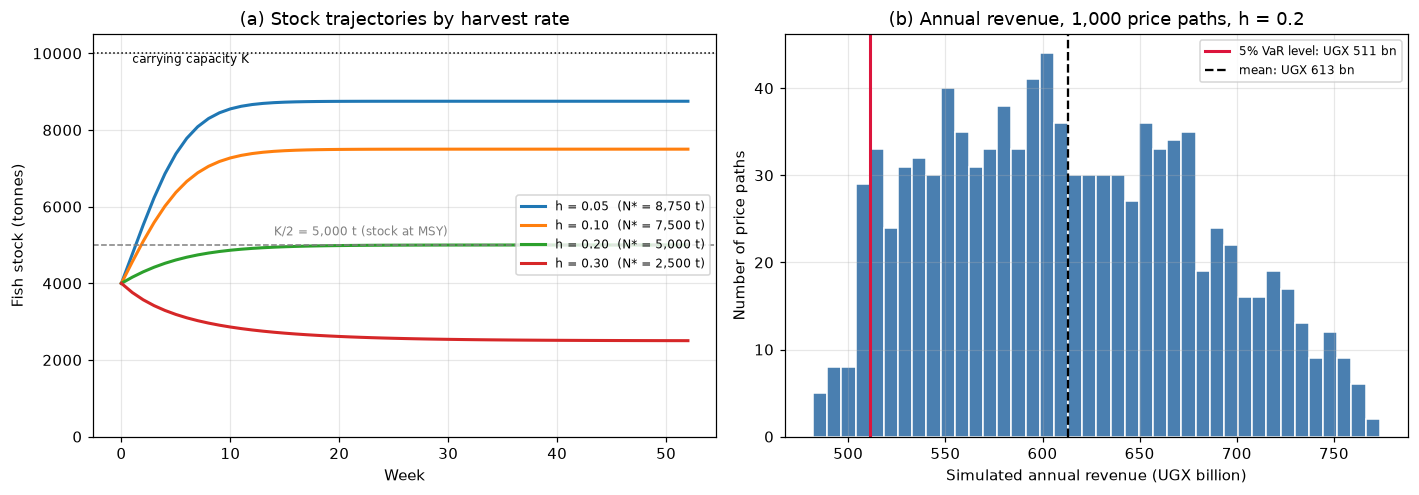

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
weeks = np.arange(WEEKS_PER_YEAR + 1)
for h, traj in trajectories.items():
    ax.plot(weeks, traj, lw=2, label=f"h = {h:.2f}  (N* = {FishStock(h=h).equilibrium_stock():,.0f} t)")
ax.axhline(5_000, color="grey", ls="--", lw=1)
ax.text(14, 5_250, "K/2 = 5,000 t (stock at MSY)", fontsize=8, color="grey")
ax.axhline(10_000, color="black", ls=":", lw=1)
ax.text(1, 9_750, "carrying capacity K", fontsize=8)
ax.set_xlabel("Week")
ax.set_ylabel("Fish stock (tonnes)")
ax.set_title("(a) Stock trajectories by harvest rate")
ax.set_ylim(0, 10_500)
ax.legend(fontsize=8, loc="center right")

ax = axes[1]
h_show = 0.20
annual_bn = annual_by_h[h_show] / 1e9
v = assessor.value_at_risk(annual_by_h[h_show])
ax.hist(annual_bn, bins=40, color="#4a7fb0", edgecolor="white")
ax.axvline(v["quantile"] / 1e9, color="crimson", lw=2, label=f"5% VaR level: UGX {v['quantile'] / 1e9:,.0f} bn")
ax.axvline(v["mean"] / 1e9, color="black", ls="--", label=f"mean: UGX {v['mean'] / 1e9:,.0f} bn")
ax.set_xlabel("Simulated annual revenue (UGX billion)")
ax.set_ylabel("Number of price paths")
ax.set_title(f"(b) Annual revenue, {N_PATHS:,} price paths, h = {h_show}")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("figures/p3_stock_and_var.png", bbox_inches="tight")
plt.show()

Chart (a) shows the key point of Task 6: h = 0.30 pulls the stock well below the MSY line, while h = 0.20 holds it there. Chart (b) shows that even at the best harvest rate, one year in twenty brings in about UGX 100 bn less than the average year purely because of price risk. The left tail is cut off by the UGX 9,000 price floor, which produces the pile-up near the lower end.

## Extension: an 8-week closed season over 5 years

Uganda already uses closed seasons and gear restrictions on Lake Victoria to protect breeding fish. I close weeks 8–15 of every year (roughly March–April, the start of the long rains, when many species breed) and compare 5-year (260-week) revenue. Both runs use the same 260-week price path, so the difference comes only from the closure.

In [9]:
WEEKS_5Y = 5 * WEEKS_PER_YEAR
CLOSED = range(8, 16)
price_5y = price_model.simulate(WEEKS_5Y)
ext = []
for h in HARVEST_RATES:
    open_run = FishStock(h=h).simulate(WEEKS_5Y)
    closed_run = FishStock(h=h, closed_weeks=CLOSED).simulate(WEEKS_5Y)
    r_open = weekly_revenue(open_run.harvest, price_5y).sum()
    r_closed = weekly_revenue(closed_run.harvest, price_5y).sum()
    ext.append({"h": h, "5-yr revenue, no closure (UGX bn)": r_open / 1e9,
                "5-yr revenue, 8-wk closure (UGX bn)": r_closed / 1e9,
                "change (%)": 100 * (r_closed / r_open - 1),
                "min stock, no closure (t)": open_run.stock.min(),
                "min stock, closure (t)": closed_run.stock.min(),
                "stock at yr 5, closure (t)": closed_run.final_stock})
closed_table = pd.DataFrame(ext).set_index("h")
closed_table

,"5-yr revenue, no closure (UGX bn)","5-yr revenue, 8-wk closure (UGX bn)",change (%),"min stock, no closure (t)","min stock, closure (t)","stock at yr 5, closure (t)"
h,,,,,,
0.05,"1,106.81",937.97,-15.25,"4,000.00","4,000.00","8,750.00"
0.10,"1,899.07","1,629.72",-14.18,"4,000.00","4,000.00","7,500.00"
0.20,"2,544.67","2,294.03",-9.85,"4,000.00","4,000.00","5,000.66"
0.30,"1,958.02","2,072.84",5.86,"2,500.00","2,515.13","2,535.47"


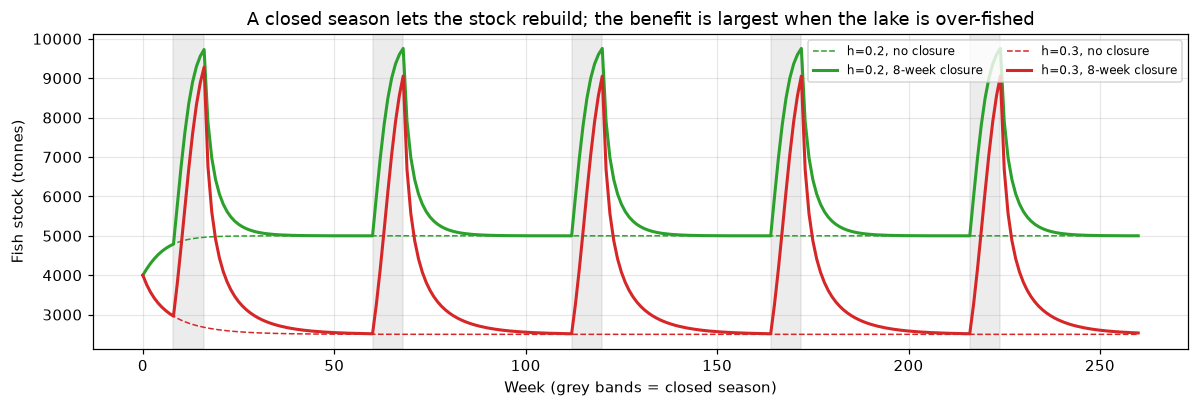

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.8))
for h, col in [(0.20, "tab:green"), (0.30, "tab:red")]:
    ax.plot(FishStock(h=h).simulate(WEEKS_5Y).stock, color=col, lw=1, ls="--", label=f"h={h}, no closure")
    ax.plot(FishStock(h=h, closed_weeks=CLOSED).simulate(WEEKS_5Y).stock, color=col, lw=2, label=f"h={h}, 8-week closure")
for yr in range(5):
    ax.axvspan(yr * 52 + 8, yr * 52 + 16, color="grey", alpha=0.15)
ax.set_xlabel("Week (grey bands = closed season)")
ax.set_ylabel("Fish stock (tonnes)")
ax.set_title("A closed season lets the stock rebuild; the benefit is largest when the lake is over-fished")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig("figures/p3_closed_season.png", bbox_inches="tight")
plt.show()

**Effect of the closed season.** The answer depends on how hard the lake is fished. At h ≤ 0.20 the closure **costs** revenue (about 10–15 % over 5 years): the stock is already at or above its productive level, so eight lost weeks are simply lost catch. At **h = 0.30, the closure increases 5-year revenue** (about +6 %). During the closure the depleted stock regrows quickly (logistic growth is fastest at K/2), and the co-op then harvests a larger stock for the remaining 44 weeks. A closed season is therefore most valuable as a corrective for over-fishing. For a co-op fishing at or below MSY, a lower year-round harvest rate achieves the same conservation goal at lower cost. This model ignores the main biological reason for closures (protecting spawning fish and juveniles), so it probably *understates* their benefit.

## Findings & Limitations

**Findings.** Replacing Fibonacci growth with logistic growth changes the answer from "the stock grows forever" to a clear trade-off. Harvesting at **h = 0.20 (half the growth rate) gives the maximum sustainable yield of 1,000 t/week**, keeps the stock at half of carrying capacity, and produces the highest and steadiest revenue. Lower rates are safe but forgo income. h = 0.30 is the dangerous case: it beats h = 0.10 in year one only by running down the stock to 25 % of capacity, after which its sustainable yield is no better. Revenue risk is "Moderate" for most rates and "Low" at MSY. Even so, price movements alone create a 5 % VaR shortfall of roughly UGX 100 bn a year at MSY, so the co-op needs reserves or forward contracts with exporters. The old "variance > 50,000" rule is meaningless because variance is in UGX², and its verdict flips when the unit changes. CV is unit-free and comparable across scenarios.

**Limitations.** r = 0.4 *per week* is far faster than for Nile perch or tilapia. K and N₀ look like a lake-wide stock, not one co-op's share, so the revenue magnitudes (billions of UGX per week) are implausible for a single cooperative. Harvest is deterministic and proportional to stock, with no recruitment shocks, environmental noise (water hyacinth, oxygen), or illegal fishing by others sharing the same stock. The price walk is independent of supply, but in reality a larger catch depresses the price. The CV bands and the closed-season timing are judgement calls. Despite all this, the main qualitative result (MSY at h = r/2 and the "stock-mining" trap) is robust because it follows from the model's structure.